### Variational Autoencoder
> following https://mbernste.github.io/posts/vae/

<img src="./images/drawing.png" alt="drawing" width="50%"/>


In [1]:
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from dataclasses import dataclass

device = 'cpu'
if torch.cuda.is_available():
    device = 'cuda'
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = 'mps'
print(device)

cuda


In [2]:
from torch.utils.data import TensorDataset, DataLoader

batch_size = 32

def read_idx3_images(path):
    with open(path, 'rb') as f:
        # skip the 16 byte header: magic number(4), count(4), rows(4), cols(4)
        data = np.fromfile(f, dtype=np.uint8, offset=16)
    # reshape to (#images, 784) 
    return data.reshape(-1, 784).astype(np.float32) / 255.0

def read_idx1_labels(path):
    with open(path, 'rb') as f:
        data = np.fromfile(f, dtype=np.uint8, offset=8)
    return data.astype(np.int64)

def getDataLoader(split):
    images = read_idx3_images('data/train-images-idx3-ubyte') if (split == 'train') else read_idx3_images('data/t10k-images-idx3-ubyte')
    labels = read_idx1_labels('data/train-labels-idx1-ubyte') if (split == 'train') else read_idx1_labels('data/t10k-labels-idx1-ubyte')
    
    x_train = torch.tensor(images, dtype=torch.float32)
    y_train = torch.tensor(labels, dtype=torch.long)
    train_ds = TensorDataset(x_train, y_train)
    
    print(x_train.shape)
    print(f"1 epoch = {10000/batch_size} batches")
    return DataLoader(train_ds, batch_size=batch_size, shuffle=True, )

$\text{ELBO}(\phi, \theta) = \sum_{i=1}^{n} E_{z_{i} \sim q} \left[\log p_{\theta}\left(x_{i} | z_{i}\right) - KL \left(q\left(z_{i} | x_{i}\right) \parallel p(z_{i})\right)\right]$

$KL \left(q\left(z_{i} | x_{i}\right) \parallel p(z_{i})\right) = -\frac{1}{2}\sum_{j=1}^{J} \left(1 + \log \sigma_{j}^{2} - \mu_{j}^{2} - e^{ \log \sigma_{j}^{2}}  \right)$

In [3]:
# hyperparams
@dataclass
class VAEConfig:
    input_dim: int = 784
    hidden_dim: int = 512
    hidden_layers: int = 2
    latent_channels: int = 32
    lr: float = 3e-4

class FFN(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        
        self.layers = nn.Sequential(
            nn.Linear(input_dim, output_dim),
            nn.LeakyReLU(0.2)
        )
        
    def forward(self, x):
        return self.layers(x)


class VAE(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        assert config.hidden_dim % (2**config.hidden_layers) == 0, "not divisible by layers"
        
        self.encode = nn.Sequential(
            FFN(config.input_dim, config.hidden_dim),
            *[FFN(config.hidden_dim // (2 ** i), config.hidden_dim // (2 ** (i+1))) for i in range(config.hidden_layers)]
        )

        z_dim = config.hidden_dim // (2 ** config.hidden_layers)

        self.mulayer = nn.Linear(z_dim, config.latent_channels)
        self.logvar = nn.Linear(z_dim, config.latent_channels)

        
        self.decode = nn.Sequential(
            FFN(config.latent_channels, z_dim),
            *[FFN(z_dim * (2 ** i), z_dim*(2 ** (i+1))) for i in range(config.hidden_layers)],
            nn.Linear(config.hidden_dim, config.input_dim), # proj back up
        )

    def forward(self, x, targets=None, beta=1.0):
        x = self.encode(x)
        mu = self.mulayer(x)
        logvar = self.logvar(x)
        
        reparam = mu + torch.randn_like(logvar) * torch.exp(0.5 * logvar)
        output = self.decode(reparam)
        
        if targets is None:
            loss = None
        else:
            bce_loss = F.binary_cross_entropy_with_logits(output, targets, reduction="sum") / batch_size
            # mse_loss = F.mse_loss(input=output, target=targets, reduction="sum") / batch_size
            kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / batch_size
            
            loss = bce_loss + (beta) * kl_loss
        return output, loss, bce_loss, kl_loss


**small note:** recon and kl loss must be scaled properly. kl loss is regularization so a scaling of $\beta$ too high causes a posterior collapse leading to averages.

In [4]:
import os
def save_checkpoint(raw_model, step):
    checkpoint = {
        'model': raw_model.state_dict(),
        'step': step
    }
    torch.save(checkpoint, f"vaemnist_{step}.pt")

def load_checkpoint(ckpt_path, model):
    if not (os.path.exists(ckpt_path)):
        return 1

    print("Checkpoint found!")
    checkpoint = torch.load(ckpt_path, weights_only=True)
    model.load_state_dict(checkpoint['model'])

    return checkpoint['step']


@torch.no_grad()
def test_eval(model):
    model.eval()

    total_loss = 0
    batches = 0
    with torch.no_grad():
        for _, (images, _) in enumerate(test_loader):
                with torch.autocast(device_type=device, dtype=torch.bfloat16):
                    images = images.to(device)
                    _, loss, _, _ = model(images, images)

                # if (batch_idx > batches):
                #     break
                total_loss += (loss.item())
                batches += 1

    total_loss /= batches
    model.train()
    return total_loss
    

In [5]:
def get_lr(iter):
    return 3e-4 - (6e-9 * iter)

In [6]:
model = VAE(VAEConfig()).to(device)
#model.load_state_dict(torch.load("vaemnist.pt", weights_only=True))
step = load_checkpoint(ckpt_path="pt/vaemnist_31250.pt", model=model)
optimizer = torch.optim.AdamW(model.parameters(), lr=model.config.lr)

train_loader = getDataLoader('train')
test_loader = getDataLoader('test')

expected, outputs = [], []
divergence_warmup = 10000


Checkpoint found!
torch.Size([60000, 784])
1 epoch = 312.5 batches
torch.Size([10000, 784])
1 epoch = 312.5 batches


In [7]:
# for epoch in range(2):
model.train()
while (step < 32000):
    for batch_idx, (images, _) in enumerate(train_loader):
        
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type=device, dtype=torch.bfloat16):
            images = images.to(device)
            output, loss, recon_loss, kl_loss = model(images, images)

        loss.backward()
        optimizer.step()
        
        
        lr = get_lr(step)
        for param_group in optimizer.param_groups:
            param_group['lr'] = lr
        
        if (step % 1000 == 0):
            print(f"step: {step} | total loss: {loss.item():.2f} bce {recon_loss.item():.2f} kl {kl_loss.item():.2f} | test: {test_eval(model=model):.2f} | lr: {lr:.6f}")
            
        step += 1
    outputs.append(output.to(torch.float32))
    expected.append(images.to(torch.float32))



step: 32000 | total loss: 108.23 bce 94.65 kl 13.58 | test: 116.67 | lr: 0.000108
step: 33000 | total loss: 110.13 bce 94.93 kl 15.20 | test: 115.50 | lr: 0.000102


In [8]:
save_checkpoint(raw_model=model, step=step)

## Reconstruction vs Original & Generating new images

In [9]:
import matplotlib.pyplot as plt

# img = Image.fromarray((arr * 255).clip(0, 255).astype(np.uint8), mode="L")
# img.save("reconstructed.png")

from ipywidgets import interact, Layout, IntSlider
@torch.no_grad()
def show_image(i):
    batch = i//batch_size
    print(f"epoch {batch/625}, batch {batch}, total examples: {i}")
    predicted = outputs[batch][i % batch_size].cpu().detach().reshape(28, 28).numpy() # 16 is batch
    e = expected[batch][i % batch_size].cpu().detach().reshape(28, 28).numpy()
    
    plt.figure(figsize=(6, 3))
    plt.subplot(1, 2, 1)
    
    plt.imshow(predicted.squeeze(), cmap="gray", vmin=0, vmax=1)
    plt.subplot(1, 2, 2)
    plt.imshow(e, cmap="gray")
    plt.show()
    
interact(show_image, i=IntSlider(min=0, max=batch_size*(len(outputs)) - 1, layout=Layout(width='75%')))

interactive(children=(IntSlider(value=0, description='i', layout=Layout(width='75%'), max=31), Output()), _dom…

<function __main__.show_image(i)>

We can sample and generate new images from the Gaussian distrubution $N(0, 1)$ within the latent space.

torch.Size([9, 784])


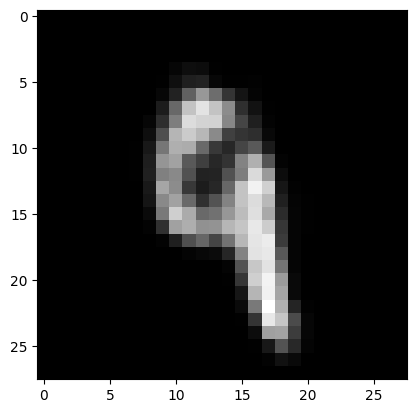

In [10]:
from torchvision.utils import save_image
total_samples = 9
test = torch.randn((total_samples, VAEConfig().latent_channels), device=device)

with torch.no_grad():
    output = torch.sigmoid(model.decode(test))
    plt.imshow(output[0].cpu().detach().reshape(28, 28).numpy(), cmap="gray")
    
    print(output.shape)
    save_image(output.view(total_samples, 1, 28, 28), "sampled.png", nrow=3)

In [11]:
import umap

latents = []
digits = []

model.eval()
with torch.no_grad():
    for batch_idx, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        mu = model.mulayer(model.encode(images))
        
        latents.append(mu.cpu().numpy())
        digits.append(labels.cpu().numpy())
        
latents = np.concatenate(latents, axis=0)
digits = np.concatenate(digits, axis=0)

In [12]:
reducer = umap.UMAP()
reducer.fit(latents)

,tqdm_kwds,"{'bar_format': '{desc}: {percentage:3....{total_fmt} [{elapsed}]', 'desc': 'Epochs completed', 'disable': True}"
,n_neighbors,15
,n_components,2
,metric,'euclidean'
,metric_kwds,None
,output_metric,'euclidean'
,output_metric_kwds,None
,n_epochs,None
,learning_rate,1.0
,init,'spectral'
,min_dist,0.1


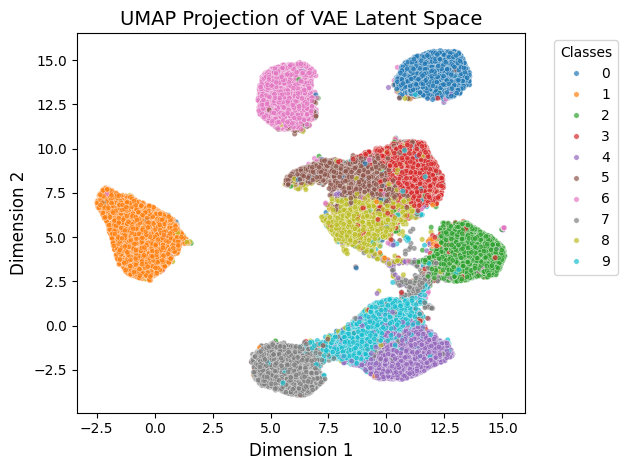

In [13]:
import seaborn as sns

sns.scatterplot(
    x=reducer.embedding_[:, 0],
    y=reducer.embedding_[:, 1],
    hue=digits,
    palette='tab10',
    alpha=0.7,
    s=15,
    legend='full'
)
plt.title('UMAP Projection of VAE Latent Space', fontsize=14)
plt.xlabel('Dimension 1', fontsize=12)
plt.ylabel('Dimension 2', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Classes')
plt.tight_layout()

plt.savefig(fname="UMAP-VAE")
plt.show()

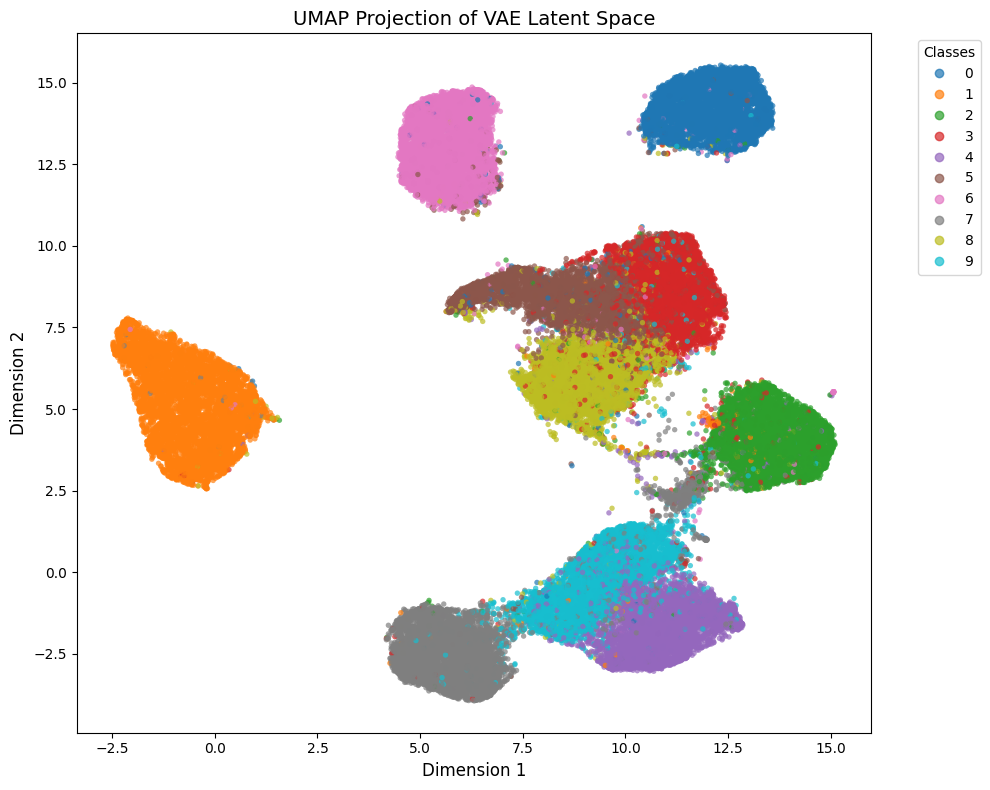

In [29]:
fig, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(
    x=reducer.embedding_[:, 0],
    y=reducer.embedding_[:, 1],
    c=digits,
    cmap='tab10',
    alpha=0.7,
    s=15,
    edgecolors='none'
)

ax.set_title('UMAP Projection of VAE Latent Space', fontsize=14)
ax.set_xlabel('Dimension 1', fontsize=12)
ax.set_ylabel('Dimension 2', fontsize=12)

ax.legend(
    *scatter.legend_elements(),
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    title='Classes'
)

plt.tight_layout()
plt.savefig('UMAP-VAE.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()